# 03 — Default Model: Logistic Regression

Spec §5.2. Data source: `panel_logistic_2021_2025.parquet` (2021–2025 originations).

Pipeline:
1. Load panel + FRED macro
2. Build loan-level feature matrix
3. Temporal train/valid/test split
4. Fit LogisticRegression(class_weight='balanced', solver='saga')
5. Calibrate with Platt scaling on validation set
6. Evaluate: ROC curve, PR curve, confusion matrix
7. SHAP feature importance
8. Serialize to artifacts/models/logistic_model.pkl

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    confusion_matrix,
    precision_recall_curve,
)

# shap is optional for this notebook. Guard the import so an environment with a
# broken binary dependency (e.g. an opencv/cv2 compiled against NumPy 1.x in a
# NumPy 2.x kernel) degrades to "skip SHAP" instead of crashing the kernel.
# NOTE: select the pyenv "Python 3 (ipykernel)" kernel, not the anaconda one —
# the anaconda env has the broken cv2/NumPy combination.
try:
    import shap
    HAS_SHAP = True
except Exception as exc:  # pylint: disable=broad-except
    shap = None
    HAS_SHAP = False
    print(f'shap unavailable ({type(exc).__name__}); SHAP section will be skipped.')

load_dotenv()
sys.path.insert(0, str(Path('..') / 'src'))
import default_model as dm
import feature_engineering as fe

PROCESSED = Path('..') / 'data' / 'processed'
FRED_DIR  = Path('..') / 'data' / 'fred'
FIGURES   = Path('..') / 'artifacts' / 'figures'
MODELS    = Path('..') / 'artifacts' / 'models'
FRED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/shreyanshsharma/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/shreyanshsharma/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/shreyanshsharma/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loo

AttributeError: _ARRAY_API not found

## 1. Load precomputed loan-level table and FRED macro

The full monthly panel (`panel_logistic_2021_2025.parquet`, 3.7 GB / 329M rows)
does **not** fit in a 16 GB kernel. We load the one-row-per-loan table built
out-of-core with DuckDB via `python src/build_model_aggregates.py`.

In [2]:
# One row per loan, built out-of-core with DuckDB (see build_model_aggregates.py).
loan_level_path = PROCESSED / 'loan_level_logistic.parquet'
if not loan_level_path.exists():
    raise FileNotFoundError(
        f'{loan_level_path} not found. First run:\n'
        '    python src/build_model_aggregates.py'
    )
loan_level = pd.read_parquet(loan_level_path)
print(f'Loan-level table: {loan_level.shape[0]:,} loans × {loan_level.shape[1]} cols')

macro = fe.fetch_macro_quarterly(
    start='2000-01-01', end='2025-12-31',
    cache_path=FRED_DIR / 'macro_quarterly.csv',
)
print(f'Macro shape: {macro.shape}, index range: {macro.index[0]} – {macro.index[-1]}')
macro.tail()

Loan-level table: 9,143,428 loans × 14 cols
Macro shape: (687, 6), index range: 1854Q4 – 2026Q2


,unemp_rate_orig,mortgage_rate_orig,fedfunds_orig,hpi_level_orig,in_recession_orig,hpi_yoy_orig
2025Q2,4.1,6.77,4.33,337.214468,0.0,0.021414
2025Q3,4.4,6.30,4.22,337.967058,0.0,0.014004
2025Q4,4.4,6.15,3.72,342.485504,0.0,0.014656
2026Q1,4.3,6.38,3.64,342.331707,0.0,0.008315
2026Q2,4.3,6.47,3.63,342.331707,0.0,0.015175


## 2. Build loan-level feature matrix

In [3]:
loan_df = fe.build_logistic_features_from_loan_level(loan_level, macro)
print(f'Loan-level dataset: {loan_df.shape}')
print(f'Default rate: {loan_df.default.mean():.4%}')
print(f'Feature columns present: {all(c in loan_df.columns for c in dm.FEATURE_COLS)}')
loan_df[dm.FEATURE_COLS].describe().round(3)

Loan-level dataset: (9143428, 35)
Default rate: 1.7190%
Feature columns present: True


,credit_score,ltv,dti,orig_interest_rate,months_remaining_ratio,loan_age_yrs,high_dti,high_ltv,low_fico,in_negative_equity,mortgage_rate_orig,unemp_rate_orig,hpi_yoy_orig,fedfunds_orig,in_recession_orig,high_dti_x_high_rate,neg_equity_x_hpi_drop,occ_S,occ_I,is_judicial
count,9141537.000,9143428.000,9143428.000,9143428.000,9143428.000,9143428.000,9143428.000,9143428.000,9143428.000,9143428.000,9143428.000,9143428.000,9143428.000,9143428.000,9143428.0,9143428.000,9143428.000,9143428.00,9143428.000,9143428.000
mean,750.932,71.530,35.492,4.329,0.884,2.915,0.248,0.266,0.040,0.000,4.715,4.492,0.129,1.831,0.0,0.142,0.000,0.03,0.060,0.426
std,45.063,18.345,9.624,1.761,0.076,1.470,0.432,0.442,0.195,0.003,1.669,0.956,0.071,2.166,0.0,0.349,0.001,0.17,0.238,0.495
min,300.000,1.000,1.000,1.500,0.329,0.000,0.000,0.000,0.000,0.000,3.010,3.500,-0.013,0.070,0.0,0.000,0.000,0.00,0.000,0.000
25%,721.000,60.000,29.000,2.875,0.853,1.583,0.000,0.000,0.000,0.000,3.110,3.700,0.049,0.080,0.0,0.000,0.000,0.00,0.000,0.000
50%,760.000,75.000,37.000,3.375,0.881,3.417,0.000,0.000,0.000,0.000,4.670,4.100,0.135,0.200,0.0,0.000,0.000,0.00,0.000,0.000
75%,788.000,85.000,43.000,6.125,0.944,4.167,0.000,1.000,0.000,0.000,6.610,5.900,0.190,4.330,0.0,0.000,0.000,0.00,0.000,1.000
max,850.000,150.000,65.000,9.750,1.000,4.750,1.000,1.000,1.000,1.000,7.310,6.100,0.212,5.330,0.0,1.000,1.000,1.00,1.000,1.000


## 3. Temporal train / valid / test split (spec §5.2)

In [4]:
train_df, valid_df, test_df = dm.temporal_split(
    loan_df, train_cutoff='2024-01-01', valid_cutoff='2024-07-01'
)
for name, split in [('Train', train_df), ('Valid', valid_df), ('Test', test_df)]:
    print(f'{name:5s}: {len(split):>8,} loans | default rate {split.default.mean():.4%}')

Train:  702,437 loans | default rate 1.0938%
Valid:  160,724 loans | default rate 2.6524%
Test : 8,280,267 loans | default rate 1.7540%


## 4–5. Fit logistic regression + Platt calibration

In [5]:
model, scaler, val_metrics = dm.train_logistic(train_df, valid_df)
print('Validation metrics:')
for key, val in val_metrics.items():
    print(f'  {key}: {val:.4f}' if isinstance(val, float) else f'  {key}: {val:,}')

Validation metrics:
  val_roc_auc: 0.6507
  val_pr_auc: 0.0432
  val_default_rate: 0.0265
  n_train: 702,224
  n_valid: 160,681


/Users/shreyanshsharma/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 6. Evaluate on test set — ROC, PR curve, confusion matrix

In [6]:
test_metrics = dm.evaluate_on_test(model, scaler, test_df)
print('Test metrics (spec §5.2 targets: ROC-AUC ~0.83, default rate ~0.32%):')
for key, val in test_metrics.items():
    print(f'  {key}: {val:.4f}' if isinstance(val, float) else f'  {key}: {val:,}')

Test metrics (spec §5.2 targets: ROC-AUC ~0.83, default rate ~0.32%):
  test_roc_auc: 0.6084
  test_pr_auc: 0.0255
  test_default_rate: 0.0175
  n_test: 8,278,632


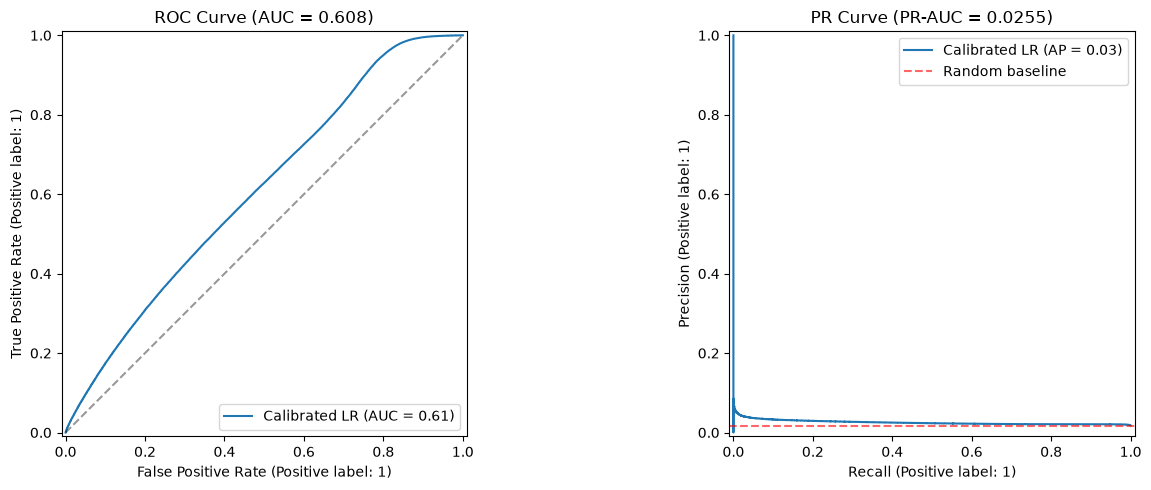

In [7]:
# Get probabilities for plots
x_test_raw, y_test = dm._prepare_xy(test_df, dm.FEATURE_COLS)
x_test_scaled = scaler.transform(x_test_raw)
y_prob_test = model.predict_proba(x_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_test, ax=axes[0], name='Calibrated LR')
axes[0].plot([0,1],[0,1],'k--',alpha=0.4)
axes[0].set_title(f'ROC Curve (AUC = {test_metrics["test_roc_auc"]:.3f})')

PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, ax=axes[1], name='Calibrated LR')
axes[1].axhline(y_test.mean(), color='r', linestyle='--', alpha=0.6, label='Random baseline')
axes[1].set_title(f'PR Curve (PR-AUC = {test_metrics["test_pr_auc"]:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'logistic_roc_pr_curves.png', bbox_inches='tight')
plt.show()

In [8]:
# Precision/Recall at multiple thresholds
prec, rec, thresholds = precision_recall_curve(y_test, y_prob_test)
threshold_df = pd.DataFrame({'threshold': thresholds, 'precision': prec[:-1], 'recall': rec[:-1]})

# Find threshold closest to 95th percentile score
p95 = np.percentile(y_prob_test, 95)
closest = (threshold_df['threshold'] - p95).abs().idxmin()
row = threshold_df.loc[closest]
print(f'At 95th pct score threshold ({p95:.4f}):')
print(f'  Precision: {row.precision:.3f} (expect ~2%)')
print(f'  Recall:    {row.recall:.3f} (expect ~31%)')

At 95th pct score threshold (0.1485):
  Precision: 0.033 (expect ~2%)
  Recall:    0.095 (expect ~31%)


## 7. SHAP feature importance

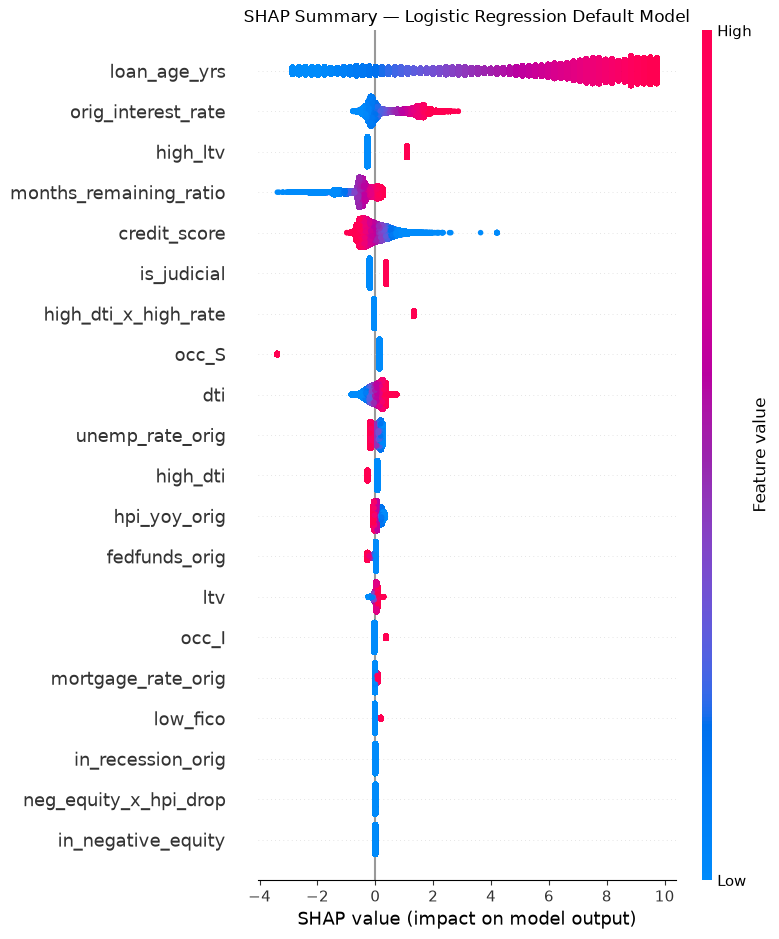

In [9]:
if not HAS_SHAP:
    print('shap not available in this kernel — skipping SHAP summary. '
          'Select the pyenv "Python 3 (ipykernel)" kernel to enable it.')
else:
    x_train_raw, _ = dm._prepare_xy(train_df, dm.FEATURE_COLS)

    # Use a 1000-sample background for speed
    rng = np.random.default_rng(42)
    bg_idx = rng.choice(len(x_train_raw), size=min(1000, len(x_train_raw)), replace=False)
    x_background = x_train_raw[bg_idx]

    shap_values, expected_val = dm.compute_shap_values(
        model, scaler, x_background, x_test_raw
    )

    shap.summary_plot(
        shap_values, x_test_raw,
        feature_names=dm.FEATURE_COLS,
        show=False,
    )
    plt.title('SHAP Summary — Logistic Regression Default Model')
    plt.tight_layout()
    plt.savefig(FIGURES / 'logistic_shap_summary.png', bbox_inches='tight')
    plt.show()

## 8. Serialize model

In [10]:
model_path = dm.save_model(model, scaler, out_dir=MODELS)
print(f'Model saved to: {model_path}')

# Verify round-trip load
bundle = dm.load_model(model_path)
y_prob_reload = bundle['model'].predict_proba(x_test_scaled)[:, 1]
assert np.allclose(y_prob_test, y_prob_reload), 'Round-trip probabilities differ!'
print('Round-trip load: probabilities match ✓')
print(f'\nFinal test ROC-AUC: {test_metrics["test_roc_auc"]:.4f}')

Model saved to: ../artifacts/models/logistic_model.pkl
Round-trip load: probabilities match ✓

Final test ROC-AUC: 0.6084
